# Exp0.2.2 — Capacity-preserving anti-persistent-firing loss

Analysis-only notebook. Training, checkpoint evaluation, and per-run 2x3 diagnostic figures are produced by the Slurm pipeline. This notebook only reads finalized artifacts.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_0_2_2_capacity_preserving_loss' / 'capacity_preserving_loss_v1'
summary = pd.read_csv(ROOT / 'summary.csv')
comparison = pd.read_csv(ROOT / 'comparison_summary.csv')
calibration = pd.read_csv(ROOT / 'calibration_summary.csv')
history = pd.read_csv(ROOT / 'history_long.csv')
shift_history = pd.read_csv(ROOT / 'shift_history_long.csv')
display(summary.sort_values(['architecture', 'test_balanced_accuracy'], ascending=[True, False]))

,architecture,condition,seed,best_epoch,best_val_balanced_accuracy,best_val_task_ce,test_balanced_accuracy,test_accuracy,test_macro_f1,test_task_ce,test_long_valid_fr_hz,test_long_tail_fr_hz,test_long_tail_valid_ratio,output_weight_energy_long_fraction,output_weight_norm_s6,output_weight_norm_s7
11,mid_long,sat_relative_tail,37,49,0.377916,1.951275,0.462628,0.479452,0.459625,1.841630,16.356464,29.187489,1.784462,0.331506,0.251812,0.238837
2,mid_long,wc_only,37,50,0.382413,1.944561,0.447213,0.458904,0.443413,1.800495,17.010571,28.969684,1.703040,0.333215,0.249284,0.241808
5,mid_long,sat,37,50,0.382413,1.944561,0.447213,0.458904,0.443413,1.800495,17.010571,28.969684,1.703040,0.333215,0.249284,0.241808
14,mid_long,sat_relative_tail_capacity,37,37,0.352754,1.939835,0.421991,0.438356,0.415634,1.842059,16.230111,29.421774,1.812789,0.322977,0.228527,0.219005
8,mid_long,relative_tail,37,37,0.365248,1.951840,0.387632,0.397260,0.372897,1.901545,16.537978,30.057060,1.817457,0.327244,0.229663,0.219185
1,mid_long,wc_only,23,45,0.372529,1.877298,0.370399,0.383562,0.366851,1.898237,16.938244,25.970680,1.533257,0.359220,0.258814,0.255022
4,mid_long,sat,23,45,0.372529,1.877298,0.370399,0.383562,0.366851,1.898237,16.938244,25.970680,1.533257,0.359220,0.258814,0.255022
0,mid_long,wc_only,11,48,0.375307,1.969815,0.348253,0.363014,0.315731,2.017557,14.016599,23.018368,1.642222,0.336549,0.277017,0.258992
3,mid_long,sat,11,48,0.375307,1.969815,0.348253,0.363014,0.315731,2.017557,14.016599,23.018368,1.642222,0.336549,0.277017,0.258992
12,mid_long,sat_relative_tail_capacity,11,48,0.323250,2.087047,0.341805,0.349315,0.322460,2.042420,12.892423,20.313249,1.575596,0.354761,0.285339,0.264936


## Final comparison
Primary classification endpoint is validation-selected test balanced accuracy. The firing endpoint is whether long valid FR is preserved while long tail/valid ratio falls.

In [3]:
cols = [c for c in [
    'architecture', 'condition',
    'best_val_balanced_accuracy_mean', 'test_balanced_accuracy_mean',
    'test_long_valid_fr_hz_mean', 'test_long_tail_fr_hz_mean',
    'test_long_tail_valid_ratio_mean',
    'output_weight_energy_long_fraction_mean',
    'output_weight_norm_s6_mean', 'output_weight_norm_s7_mean',
] if c in comparison.columns]
display(comparison[cols].sort_values(['architecture', 'test_balanced_accuracy_mean'], ascending=[True, False]))

,architecture,condition,best_val_balanced_accuracy_mean,test_balanced_accuracy_mean,test_long_valid_fr_hz_mean,test_long_tail_fr_hz_mean,test_long_tail_valid_ratio_mean,output_weight_energy_long_fraction_mean,output_weight_norm_s6_mean,output_weight_norm_s7_mean
1,mid_long,sat,0.376750,0.388622,15.988471,25.986244,1.626173,0.342995,0.261705,0.251941
4,mid_long,wc_only,0.376750,0.388622,15.988471,25.986244,1.626173,0.342995,0.261705,0.251941
2,mid_long,sat_relative_tail,0.332139,0.359609,12.043254,20.649340,1.708282,0.319995,0.238732,0.235156
3,mid_long,sat_relative_tail_capacity,0.327022,0.357046,11.212934,19.205365,1.711142,0.321626,0.236347,0.236547
0,mid_long,relative_tail,0.354559,0.353514,13.171637,22.876094,1.724632,0.330352,0.245671,0.241250
9,short_mid_long,wc_only,0.159854,0.165649,5.534370,10.795482,1.955934,0.340436,0.218603,0.224457
6,short_mid_long,sat,0.162081,0.141925,4.950950,10.128518,2.065871,0.338099,0.208966,0.218686
5,short_mid_long,relative_tail,0.154365,0.133478,3.569356,7.456724,2.154664,0.343089,0.208112,0.216872
8,short_mid_long,sat_relative_tail_capacity,0.155026,0.133450,4.254599,8.544558,2.032304,0.340043,0.208925,0.208607
7,short_mid_long,sat_relative_tail,0.149272,0.131917,3.871080,7.836212,2.108050,0.338281,0.222447,0.228393


## Mean train/validation balanced accuracy across seeds

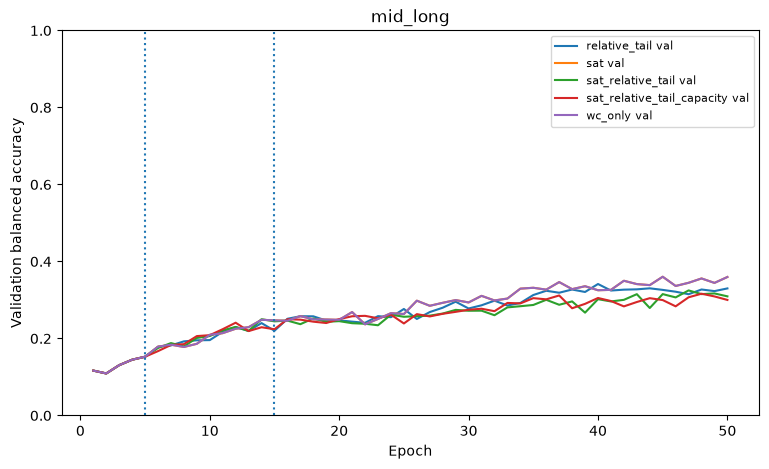

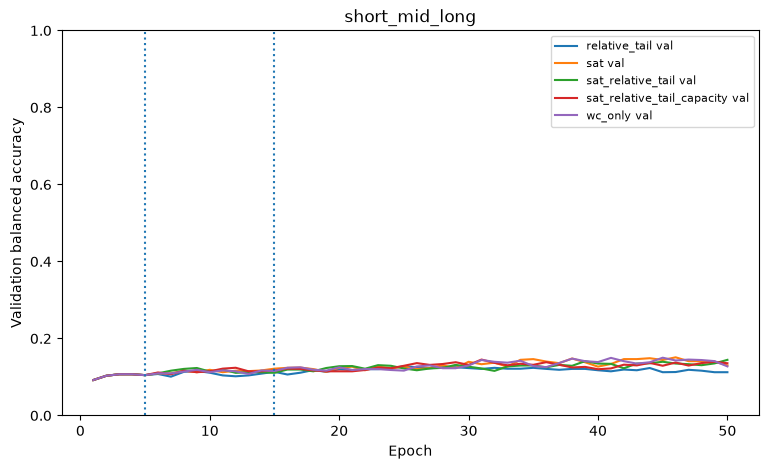

In [4]:
for architecture in sorted(history['architecture'].unique()):
    frame = history[history['architecture'] == architecture]
    fig, ax = plt.subplots(figsize=(9, 5))
    for condition, group in frame.groupby('condition'):
        curve = group.groupby('epoch', as_index=False)['val_balanced_accuracy'].mean()
        ax.plot(curve['epoch'], curve['val_balanced_accuracy'], label=f'{condition} val')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation balanced accuracy')
    ax.set_title(architecture)
    ax.axvline(5, linestyle=':')
    ax.axvline(15, linestyle=':')
    ax.legend(fontsize=8)
    plt.show()

## Loss decomposition
The key optimization view overlays task loss, weighted regularizer contribution, and total loss.

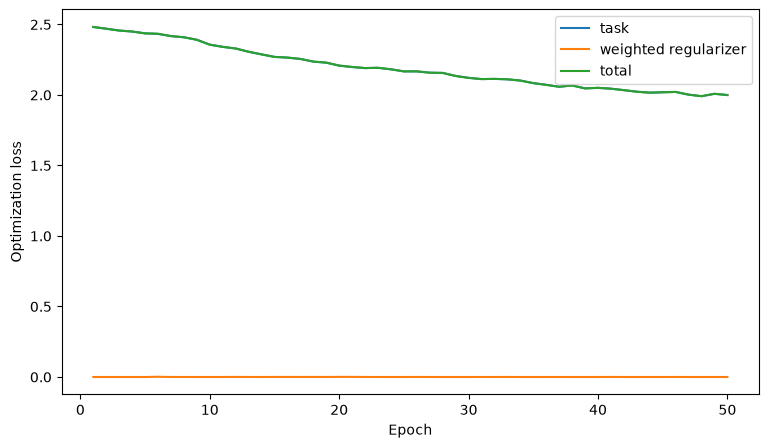

In [5]:
ARCHITECTURE = 'short_mid_long'
CONDITION = 'sat_relative_tail_capacity'
SEED = 11
frame = history[(history.architecture == ARCHITECTURE) & (history.condition == CONDITION) & (history.seed == SEED)].sort_values('epoch')
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frame['epoch'], frame['train_optim_task_loss'], label='task')
ax.plot(frame['epoch'], frame['train_optim_weighted_reg_loss'], label='weighted regularizer')
ax.plot(frame['epoch'], frame['train_optim_total_loss'], label='total')
ax.set_xlabel('Epoch')
ax.set_ylabel('Optimization loss')
ax.legend()
plt.show()

## Long-timescale firing dynamics and output utilization

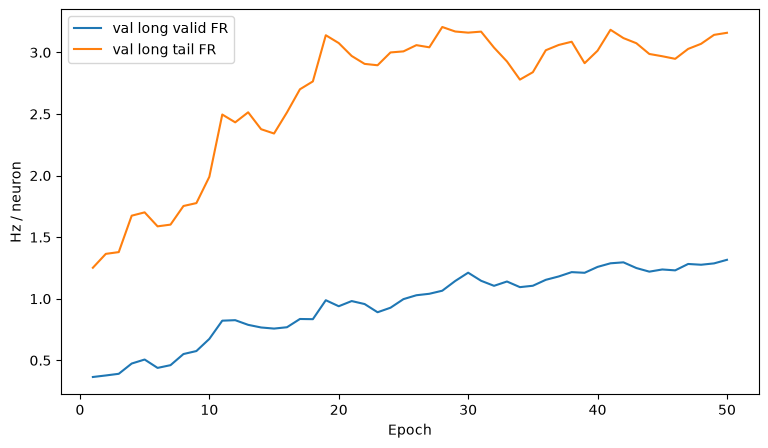

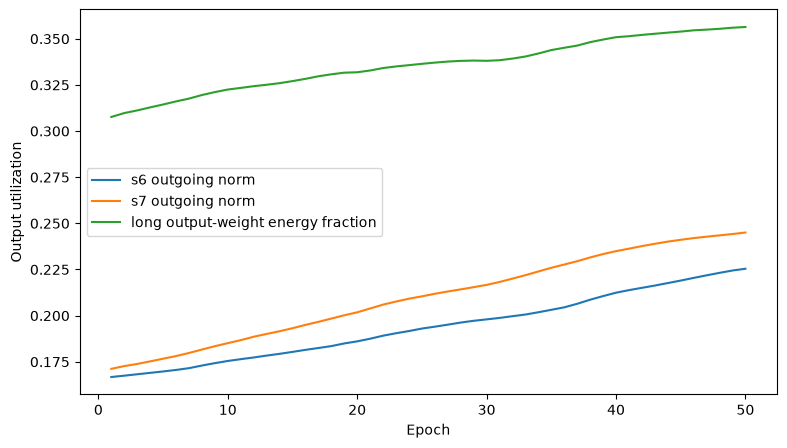

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frame['epoch'], frame['val_long_valid_fr_hz'], label='val long valid FR')
ax.plot(frame['epoch'], frame['val_long_tail_fr_hz'], label='val long tail FR')
ax.set_xlabel('Epoch')
ax.set_ylabel('Hz / neuron')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frame['epoch'], frame['output_weight_norm_s6'], label='s6 outgoing norm')
ax.plot(frame['epoch'], frame['output_weight_norm_s7'], label='s7 outgoing norm')
ax.plot(frame['epoch'], frame['output_weight_energy_long_fraction'], label='long output-weight energy fraction')
ax.set_xlabel('Epoch')
ax.set_ylabel('Output utilization')
ax.legend()
plt.show()

## Calibration
Use this table to verify that the non-baseline regularizers were calibrated from the exact shared epoch-5 fork point and that raw gradient scales are not degenerate.

In [7]:
display(calibration.sort_values(['architecture', 'condition', 'seed']))

,architecture,condition,seed,kappa,median_raw_grad_ratio,calibration_batches,active_calibration_batches,inactive_calibration_batches,calibration_status
6,mid_long,relative_tail,11,5.953249e-11,8.398775e+08,5,0,0,legacy
7,mid_long,relative_tail,23,3.287266e-05,1.521021e+03,5,0,0,legacy
8,mid_long,relative_tail,37,3.232396e-11,1.546840e+09,5,0,0,legacy
3,mid_long,sat,11,1.000000e+00,0.000000e+00,5,0,5,inactive_regularizer_unit_scale
4,mid_long,sat,23,1.000000e+00,0.000000e+00,5,0,5,inactive_regularizer_unit_scale
5,mid_long,sat,37,1.000000e+00,0.000000e+00,5,0,5,inactive_regularizer_unit_scale
9,mid_long,sat_relative_tail,11,8.834724e-10,5.659486e+07,5,0,0,legacy
10,mid_long,sat_relative_tail,23,4.800502e-05,1.041558e+03,5,0,0,legacy
11,mid_long,sat_relative_tail,37,2.419881e-11,2.066217e+09,5,0,0,legacy
12,mid_long,sat_relative_tail_capacity,11,9.339157e-10,5.353802e+07,5,0,0,legacy
